# 📝 LLM Instruction Fine-tuning (SFT)
Supervised Fine-Tuning (SFT) of GPT-2 (355M) on an Alpaca-style instruction dataset.

**Pipeline overview:**
1. Setup – model architecture + GPT-2 pretrained weights  
2. Download & format instruction dataset (Alpaca format)  
3. Custom collate function & DataLoaders  
4. Baseline evaluation (before fine-tuning)  
5. Train with `train_model_simple`  
6. Extract & save model responses  
7. Automated evaluation with Llama-3 via Hugging Face  


## Section 1 — Setup: Install dependencies & define model architecture

In [1]:
# Install required packages (uncomment if running for the first time)
# !pip install torch tiktoken tensorflow tqdm numpy matplotlib transformers accelerate huggingface_hub

import torch
import torch.nn as nn
import numpy as np
import tiktoken


### 1.1 GPT-2 Model Architecture

In [2]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), "d_out must be divisible by num_heads"
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim  = d_out // num_heads
        self.W_query   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key     = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj  = nn.Linear(d_out, d_out)
        self.dropout   = nn.Dropout(dropout)
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, n, d_in = x.shape
        q = self.W_query(x).view(b, n, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.W_key(x).view(b, n, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.W_value(x).view(b, n, self.num_heads, self.head_dim).transpose(1, 2)
        attn = (q @ k.transpose(-2, -1)) / (self.head_dim ** 0.5)
        attn = attn.masked_fill(self.mask[:n, :n].bool(), float("-inf"))
        attn = torch.softmax(attn, dim=-1)
        attn = self.dropout(attn)
        out  = (attn @ v).transpose(1, 2).contiguous().view(b, n, self.d_out)
        return self.out_proj(out)


class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps   = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var  = x.var(dim=-1,  keepdim=True, unbiased=False)
        return self.scale * (x - mean) / torch.sqrt(var + self.eps) + self.shift


class GELU(nn.Module):
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * x**3)))


class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )
    def forward(self, x):
        return self.layers(x)


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att  = MultiHeadAttention(
            d_in=cfg["emb_dim"], d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"], dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff    = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        x = x + self.drop_shortcut(self.att(self.norm1(x)))
        x = x + self.drop_shortcut(self.ff(self.norm2(x)))
        return x


class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb    = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb    = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb   = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(*[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head   = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        b, seq_len = in_idx.shape
        x = self.tok_emb(in_idx) + self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        return self.out_head(x)


### 1.2 Utility functions

In [3]:
tokenizer = tiktoken.get_encoding("gpt2")

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    return torch.tensor(encoded).unsqueeze(0)

def token_ids_to_text(token_ids, tokenizer):
    return tokenizer.decode(token_ids.squeeze(0).tolist())

def generate_text_simple(model, idx, max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        idx_next = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=1)
    return idx

def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    ctx_size = model.pos_emb.weight.shape[0]
    encoded  = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(model, encoded, max_new_tokens=50, context_size=ctx_size)
    print(token_ids_to_text(token_ids, tokenizer).replace("\n", " "))
    model.train()


### 1.3 Load GPT-2 pretrained weights  
> Using GPT-2 Medium (355M) — better at following instructions than 124M.

In [4]:
import os, urllib.request, ssl

helper_url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch05/01_main-chapter-code/gpt_download.py"
)
if not os.path.exists("gpt_download3.py"):
    ssl_ctx = ssl.create_default_context()
    ssl_ctx.check_hostname = False
    ssl_ctx.verify_mode = ssl.CERT_NONE
    with urllib.request.urlopen(helper_url, context=ssl_ctx) as r:
        with open("gpt_download3.py", "wb") as f:
            f.write(r.read())
    print("Downloaded gpt_download3.py")


Downloaded gpt_download3.py


In [5]:
from gpt_download3 import download_and_load_gpt2

CHOOSE_MODEL = "gpt2-medium (355M)"   # 124M also works but 355M gives better SFT results

BASE_CONFIG = {
    "vocab_size": 50257,
    "context_length": 1024,
    "drop_rate": 0.0,
    "qkv_bias": True
}
model_configs = {
    "gpt2-small (124M)":  {"emb_dim": 768,  "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)":  {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)":    {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(model_size=model_size, models_dir="gpt2")
print("Settings:", settings)


2026-04-14 14:12:02.599180: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776175922.807012      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776175922.877728      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776175923.394802      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776175923.394845      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776175923.394848      55 computation_placer.cc:177] computation placer alr

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 1024, 'n_head': 16, 'n_layer': 24}


In [6]:
def assign(original_weight, new_weight):
    original_weight.data = torch.tensor(new_weight)
    return original_weight

def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params["wpe"])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params["wte"])
    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(params["blocks"][b]["attn"]["c_attn"]["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight   = assign(gpt.trf_blocks[b].att.W_key.weight,   k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(gpt.trf_blocks[b].att.W_value.weight, v_w.T)
        q_b, k_b, v_b = np.split(params["blocks"][b]["attn"]["c_attn"]["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias   = assign(gpt.trf_blocks[b].att.W_key.bias,   k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(gpt.trf_blocks[b].att.W_value.bias, v_b)
        gpt.trf_blocks[b].att.out_proj.weight = assign(gpt.trf_blocks[b].att.out_proj.weight, params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias   = assign(gpt.trf_blocks[b].att.out_proj.bias,   params["blocks"][b]["attn"]["c_proj"]["b"])
        gpt.trf_blocks[b].ff.layers[0].weight = assign(gpt.trf_blocks[b].ff.layers[0].weight, params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias   = assign(gpt.trf_blocks[b].ff.layers[0].bias,   params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(gpt.trf_blocks[b].ff.layers[2].weight, params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias   = assign(gpt.trf_blocks[b].ff.layers[2].bias,   params["blocks"][b]["mlp"]["c_proj"]["b"])
        gpt.trf_blocks[b].norm1.scale = assign(gpt.trf_blocks[b].norm1.scale, params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(gpt.trf_blocks[b].norm1.shift, params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(gpt.trf_blocks[b].norm2.scale, params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(gpt.trf_blocks[b].norm2.shift, params["blocks"][b]["ln_2"]["b"])
    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight  = assign(gpt.out_head.weight,  params["wte"])

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Model loaded on: {device}")


Model loaded on: cuda


## Section 2 — Instruction Dataset (Alpaca Format)
Download 1,100 instruction–response pairs and format them in the Alpaca prompt template.


In [7]:
import json, os, urllib.request, ssl

def download_and_load_file(file_path, url):
    ssl_ctx = ssl.create_default_context()
    ssl_ctx.check_hostname = False
    ssl_ctx.verify_mode = ssl.CERT_NONE
    if not os.path.exists(file_path):
        with urllib.request.urlopen(url, context=ssl_ctx) as r:
            text_data = r.read().decode("utf-8")
        with open(file_path, "w", encoding="utf-8") as f:
            f.write(text_data)
    with open(file_path, "r", encoding="utf-8") as f:
        return json.load(f)

file_path = "instruction-data.json"
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)
data = download_and_load_file(file_path, url)
print(f"Number of entries: {len(data)}")
print("\nExample entry:", data[50])


Number of entries: 1100

Example entry: {'instruction': 'Identify the correct spelling of the following word.', 'input': 'Ocassion', 'output': "The correct spelling is 'Occasion.'"}


In [8]:
def format_input(entry):
    """Convert a data entry into Alpaca-style prompt."""
    instruction_text = (
        "Below is an instruction that describes a task. "
        "Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )
    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
    return instruction_text + input_text

# Preview formatting
model_input   = format_input(data[50])
desired_resp  = f"\n\n### Response:\n{data[50]['output']}"
print(model_input + desired_resp)


Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


In [9]:
# 85 / 10 / 5 split  →  train / test / val
train_portion = int(len(data) * 0.85)
test_portion  = int(len(data) * 0.10)

train_data = data[:train_portion]
test_data  = data[train_portion : train_portion + test_portion]
val_data   = data[train_portion + test_portion:]

print(f"Train: {len(train_data)} | Test: {len(test_data)} | Val: {len(val_data)}")


Train: 935 | Test: 110 | Val: 55


## Section 3 — Custom DataLoader
Dynamic per-batch padding (more efficient than padding the full dataset to max length).  
Padding tokens in *targets* are replaced with -100 so cross-entropy ignores them.


In [10]:
from torch.utils.data import Dataset, DataLoader
from functools import partial

class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        self.encoded_texts = []
        for entry in data:
            prompt       = format_input(entry)
            response     = f"\n\n### Response:\n{entry['output']}"
            full_text    = prompt + response
            self.encoded_texts.append(tokenizer.encode(full_text))

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)


In [11]:
def custom_collate_fn(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=None,
    device="cpu"
):
    """
    Pads each batch to the longest sequence in that batch,
    and masks padding tokens in targets with -100.
    """
    batch_max_length = max(len(item) + 1 for item in batch)
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy() + [pad_token_id]
        padded   = new_item + [pad_token_id] * (batch_max_length - len(new_item))
        inputs   = torch.tensor(padded[:-1])
        targets  = torch.tensor(padded[1:])

        # Replace all-but-first padding positions in targets with ignore_index
        mask    = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        if allowed_max_length is not None:
            inputs  = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    return (
        torch.stack(inputs_lst).to(device),
        torch.stack(targets_lst).to(device)
    )

# Quick test
sample_batch = ([0,1,2,3,4], [5,6], [7,8,9])
inp, tgt = custom_collate_fn(sample_batch)
print("Inputs :", inp)
print("Targets:", tgt)


Inputs : tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
Targets: tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

customised_collate_fn = partial(
    custom_collate_fn, device=device, allowed_max_length=1024
)

batch_size = 8
torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
val_dataset   = InstructionDataset(val_data,   tokenizer)
test_dataset  = InstructionDataset(test_data,  tokenizer)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          collate_fn=customised_collate_fn, drop_last=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False,
                          collate_fn=customised_collate_fn, drop_last=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False,
                          collate_fn=customised_collate_fn, drop_last=False, num_workers=0)

# Inspect first few batches
for i, (inp, tgt) in enumerate(train_loader):
    print(f"Batch {i+1}: input {inp.shape}, target {tgt.shape}")
    if i >= 2: break


Batch 1: input torch.Size([8, 61]), target torch.Size([8, 61])
Batch 2: input torch.Size([8, 76]), target torch.Size([8, 76])
Batch 3: input torch.Size([8, 73]), target torch.Size([8, 73])


## Section 4 — Baseline Evaluation (Before Fine-tuning)
Test how the *pretrained-only* model responds to an instruction task.


In [13]:
torch.manual_seed(123)
example_input = format_input(val_data[0])
print(example_input)


Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [14]:
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(example_input, tokenizer).to(device),
    max_new_tokens=35,
    context_size=BASE_CONFIG["context_length"]
)
generated_text = token_ids_to_text(token_ids, tokenizer)
response_text  = generated_text[len(example_input):].strip()
print("Pretrained model response (before SFT):")
print(response_text)
print("\nExpected:", val_data[0]["output"])


Pretrained model response (before SFT):
### Response:

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the

Expected: The meal is cooked by the chef every day.


## Section 5 — Train the Model

In [15]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    # Flatten for cross_entropy; ignore_index=-100 masks padding
    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0, 1), target_batch.flatten(), ignore_index=-100
    )
    return loss

def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    n = len(data_loader) if num_batches is None else min(num_batches, len(data_loader))
    for i, (xb, yb) in enumerate(data_loader):
        if i >= n: break
        total_loss += calc_loss_batch(xb, yb, model, device).item()
    return total_loss / n

def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        tl = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        vl = calc_loss_loader(val_loader,   model, device, num_batches=eval_iter)
    model.train()
    return tl, vl

def train_model_simple(model, train_loader, val_loader, optimizer, device,
                       num_epochs, eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(xb, yb, model, device)
            loss.backward()
            optimizer.step()
            tokens_seen += xb.numel()
            global_step += 1
            if global_step % eval_freq == 0:
                tl, vl = evaluate_model(model, train_loader, val_loader, device, eval_iter)
                train_losses.append(tl); val_losses.append(vl)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): Train {tl:.3f} | Val {vl:.3f}")

        generate_and_print_sample(model, tokenizer, device, start_context)

    return train_losses, val_losses, track_tokens_seen


In [16]:
# Check initial loss (before training)
model.to(device)
torch.manual_seed(123)
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss   = calc_loss_loader(val_loader,   model, device, num_batches=5)
print(f"Initial train loss: {train_loss:.3f}")
print(f"Initial val   loss: {val_loss:.3f}")


Initial train loss: 3.826
Initial val   loss: 3.762


In [17]:
import time, matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

torch.manual_seed(123)
optimizer  = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.1)
num_epochs = 2   # increase to 3-5 for better results (requires more GPU time)

start = time.time()
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input(val_data[0]), tokenizer=tokenizer
)
print(f"\nTraining time: {(time.time()-start)/60:.2f} min")


Ep 1 (Step 000000): Train 3.469 | Val 3.518
Ep 1 (Step 000005): Train 1.468 | Val 1.329
Ep 1 (Step 000010): Train 1.004 | Val 1.169
Ep 1 (Step 000015): Train 0.965 | Val 1.041
Ep 1 (Step 000020): Train 0.866 | Val 1.002
Ep 1 (Step 000025): Train 1.050 | Val 1.146
Ep 1 (Step 000030): Train 0.847 | Val 0.946
Ep 1 (Step 000035): Train 0.794 | Val 0.922
Ep 1 (Step 000040): Train 0.771 | Val 0.928
Ep 1 (Step 000045): Train 0.636 | Val 0.891
Ep 1 (Step 000050): Train 0.676 | Val 0.879
Ep 1 (Step 000055): Train 0.831 | Val 0.877
Ep 1 (Step 000060): Train 0.738 | Val 0.868
Ep 1 (Step 000065): Train 0.663 | Val 0.858
Ep 1 (Step 000070): Train 0.595 | Val 0.870
Ep 1 (Step 000075): Train 0.558 | Val 0.850
Ep 1 (Step 000080): Train 0.594 | Val 0.836
Ep 1 (Step 000085): Train 0.516 | Val 0.855
Ep 1 (Step 000090): Train 0.578 | Val 0.835
Ep 1 (Step 000095): Train 0.447 | Val 0.822
Ep 1 (Step 000100): Train 0.555 | Val 0.810
Ep 1 (Step 000105): Train 0.569 | Val 0.817
Ep 1 (Step 000110): Train 0.555 

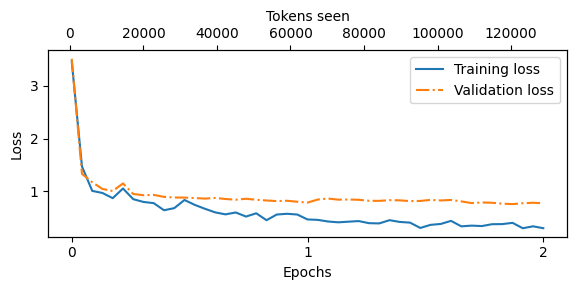

In [18]:
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(6, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs"); ax1.set_ylabel("Loss"); ax1.legend()
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout(); plt.savefig("instruction_loss_plot.pdf"); plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)


## Section 6 — Extract & Save Model Responses
Generate responses for all test examples and add them to the dataset entries for evaluation.


In [19]:
# Preview first 3 test-set responses
torch.manual_seed(123)
for entry in test_data[:3]:
    input_text     = format_input(entry)
    token_ids      = generate_text_simple(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"]
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text  = generated_text[len(input_text):].strip()

    print(f"Instruction: {entry['instruction']}")
    print(f"Expected   : {entry['output']}")
    print(f"Generated  : {response_text}")
    print("-" * 60)


Instruction: Rewrite the sentence using a simile.
Expected   : The car is as fast as lightning.
Generated  : ### Response:
The car is as fast as a cheetah.<|endoftext|>

























The car is as fast as a cheetah.<|endoftext|>












































The car sped down the road.<|endoftext|>































The car sped down the road like a bullet.<|endoftext|>
























The car sped down the road like a bullet.<|endoftext|>

















The car sped down the road like a bullet.<|endoftext|>










The car sped down the road like a bullet.<|endoftext|>






The car sped down the road like a bullet.
------------------------------------------------------------
Instruction: What type of cloud is typically associated with thunderstorms?
Expected   : The type of cloud typically associated with thunderstorms is cumulonimbus.
Generated  : ### Response:
A thunderstorm is a cumulus cumulus cumulus- cirrus (C) cumulus- cirrus (

In [20]:
from tqdm import tqdm

# Generate responses for ALL test examples
for i, entry in tqdm(enumerate(test_data), total=len(test_data)):
    input_text  = format_input(entry)
    token_ids   = generate_text_simple(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"]
    )
    generated   = token_ids_to_text(token_ids, tokenizer)
    response    = generated[len(input_text):].strip()
    test_data[i]["model_response"] = response

print(test_data[0])


100%|██████████| 110/110 [23:01<00:00, 12.56s/it]

{'instruction': 'Rewrite the sentence using a simile.', 'input': 'The car is very fast.', 'output': 'The car is as fast as lightning.', 'model_response': '### Response:\nThe car is as fast as a cheetah.<|endoftext|>\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nThe car is as fast as a cheetah.<|endoftext|>\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nThe car sped down the road.<|endoftext|>\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nThe car sped down the road like a bullet.<|endoftext|>\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nThe car sped down the road like a bullet.<|endoftext|>\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nThe car sped down the road like a bullet.<|endoftext|>\n\n\n\n\n\n\n\n\n\n\nThe car sped down the road like a bullet.<|endoftext|>\n\n\n\n\n\n\nThe car sped down the road like a bullet.'}


In [21]:
import re

# Save fine-tuned model
file_name = f"{re.sub(r'[ ()]', '', CHOOSE_MODEL)}-sft.pth"
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

# Save test results with model responses to JSON
with open("test_responses.json", "w") as f:
    json.dump(test_data, f, indent=2)
print("Responses saved to test_responses.json")

# To reload the model later:
# model.load_state_dict(torch.load(file_name, map_location=device))


Model saved as gpt2-medium355M-sft.pth
Responses saved to test_responses.json


## Section 7 — Automated Evaluation with Llama-3 (via Hugging Face)
Use a stronger open-source model to automatically score the fine-tuned model's responses.

> ⚠️ **Requirements:**  
> - Hugging Face account with access to `meta-llama/Meta-Llama-3-8B-Instruct` ([accept terms here](https://huggingface.co/meta-llama/Meta-Llama-3-8B-Instruct))  
> - A GPU with ≥16 GB VRAM (or use a smaller model variant)  
> - Replace `hf_YOUR_TOKEN_HERE` with your actual HF token  


In [27]:
# !pip install transformers accelerate huggingface_hub  # uncomment if needed
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from huggingface_hub import login

# ── Authenticate ──────────────────────────────────────────────────────────
login(token="your_token")   # replace with your actual token

# ── Load Llama-3 judge model ──────────────────────────────────────────────
model_id = "microsoft/Phi-3-mini-4k-instruct"
hf_tokenizer = AutoTokenizer.from_pretrained(model_id)
hf_model     = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)
print("PHI-3 judge model loaded.")


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

PHI-3 judge model loaded.


In [34]:
def query_model(prompt, max_new_tokens=128):
    messages = [
        {"role": "user", "content": prompt}
    ]

    inputs = hf_tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True
    )

    inputs = {k: v.to(hf_model.device) for k, v in inputs.items()}

    outputs = hf_model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        pad_token_id=hf_tokenizer.eos_token_id
    )

    response = hf_tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return response

print(query_model("What do llamas eat?"))

What do llamas eat? Llamas are herbivores and their diet consists mainly of grasses, hay, and other plant material. They are well adapted to grazing on the sparse vegetation found in their native Andean highlands. In addition to these, llamas may also consume leaves, flowers, and some fruits. They have a three-chambered stomach that allows them to digest cellulose effectively. Llamas are also known to eat small amounts of grains and commercial llama feed when available, especially in areas where their natural food sources are limited.


In [35]:
def evaluate_responses_with_llama(test_data, query_fn, num_samples=None):
    """
    Ask Llama-3 to score each (instruction, expected, generated) triple
    and return the average score (0-100).
    """
    scores = []
    samples = test_data[:num_samples] if num_samples else test_data

    for entry in tqdm(samples, desc="Evaluating"):
        prompt = (
            f"Given the instruction: {entry['instruction']}\n"
            f"Expected response: {entry['output']}\n"
            f"Model response: {entry['model_response']}\n\n"
            "Score the model response on a scale of 0 to 100, "
            "where 100 means the response is identical to the expected response. "
            "Respond with only a number."
        )
        result = query_fn(prompt, max_new_tokens=5)
        try:
            score = float(re.search(r"\d+", result).group())
            scores.append(min(score, 100.0))
        except (AttributeError, ValueError):
            print(f"Could not parse score from: '{result}'")

    avg = sum(scores) / len(scores) if scores else 0
    print(f"\nAverage score: {avg:.1f}/100 over {len(scores)} examples")
    return scores

# Evaluate (set num_samples to a small number first for a quick test)
scores = evaluate_responses_with_llama(test_data, query_model, num_samples=10)



Evaluating: 100%|██████████| 10/10 [00:13<00:00,  1.38s/it]


Average score: 1.7/100 over 10 examples
